# ConnectTel Customer Churn — Notebook 2: Exploratory Data Analysis (EDA)

## Objective

This notebook explores customer behavior and identifies patterns associated with churn, using **only the training split** (`train_raw.csv`) produced in notebook 1. The test set is kept completely untouched until final model evaluation.

The analysis focuses on:
- Customer demographics
- Subscription plans & contract details
- Billing and usage behavior
- Customer tenure
- Data-quality checks (missing values, outliers, multicollinearity) that inform the preprocessing design in notebook 3

All visualizations are saved for the final business report.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

from pathlib import Path
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
df = pd.read_csv("../data/processed/train_raw.csv")
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())


Dataset Shape: (40400, 29)

Columns: ['customer_age', 'gender', 'city', 'customer_tenure_months', 'customer_segment', 'plan_type', 'contract_type', 'number_of_services', 'monthly_data_usage_gb', 'monthly_voice_minutes', 'monthly_sms_count', 'international_usage_flag', 'network_drop_rate', 'average_download_speed', 'service_outages_last_6m', 'support_tickets_last_12m', 'avg_resolution_time_hours', 'complaints_last_12m', 'mobile_app_logins_last_30d', 'reward_points_balance', 'campaign_response_rate', 'late_payments_last_12m', 'autopay_enabled', 'billing_disputes_last_12m', 'customer_lifetime_value', 'monthly_revenue', 'retention_offer_count', 'service_region_cluster', 'churn_flag']


## 1. Churn distribution

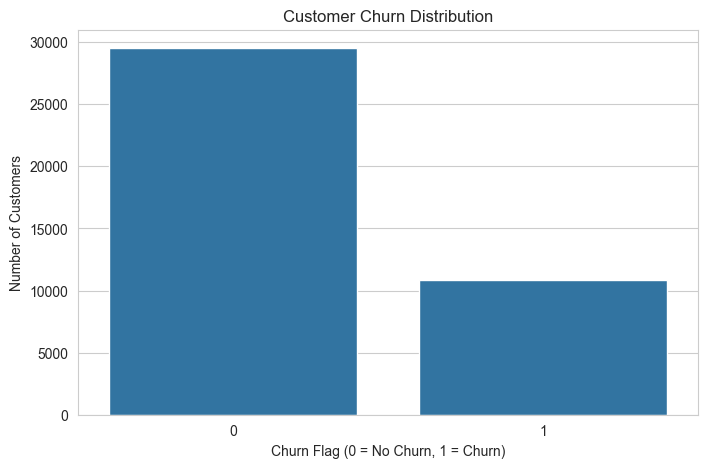

churn_flag
0    73.064356
1    26.935644
Name: proportion, dtype: float64

In [3]:
sns.countplot(data= df, x="churn_flag")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Flag (0 = No Churn, 1 = Churn)")
plt.ylabel("Number of Customers")
plt.savefig(FIG_DIR / "churn_distribution.png", bbox_inches="tight")
plt.show()

df["churn_flag"].value_counts(normalize=True) * 100


The dataset is moderately imbalanced (~27% churners), confirming the need for the SMOTE resampling already used in `model_building.ipynb`.

## 2. Churn by demographics and segment

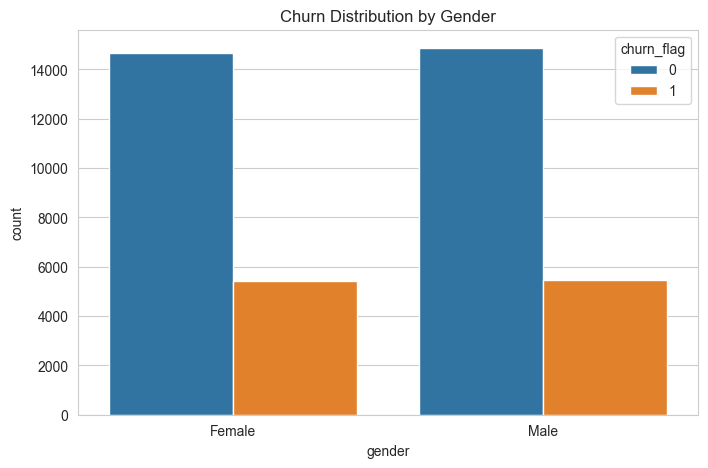

In [4]:
sns.countplot(data=df, x="gender", hue="churn_flag")
plt.title("Churn Distribution by Gender")
plt.savefig(FIG_DIR / "gender_vs_churn.png", bbox_inches="tight")
plt.show()


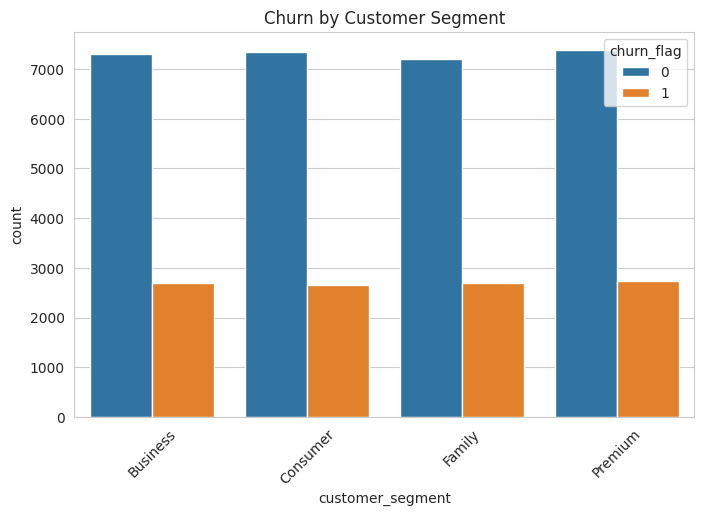

In [5]:
sns.countplot(data=df, x="customer_segment", hue="churn_flag")
plt.title("Churn by Customer Segment")
plt.xticks(rotation=45)
plt.savefig(FIG_DIR / "customer_segment_vs_churn.png", bbox_inches="tight")
plt.show()


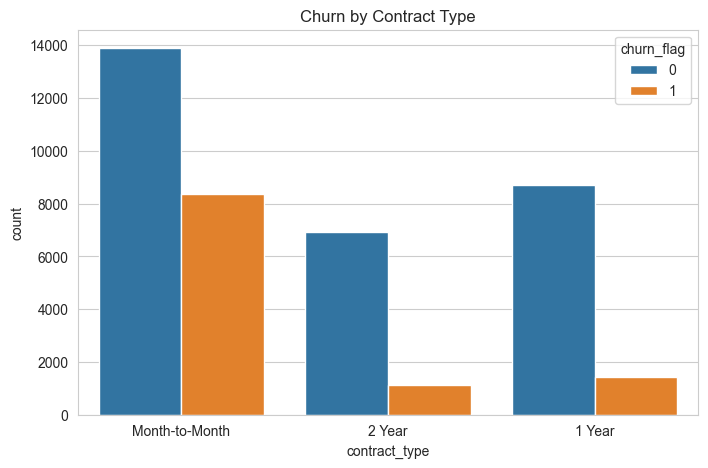

In [6]:
sns.countplot(data=df, x="contract_type", hue="churn_flag")
plt.title("Churn by Contract Type")
plt.savefig(FIG_DIR / "contract_type_vs_churn.png", bbox_inches="tight")
plt.show()


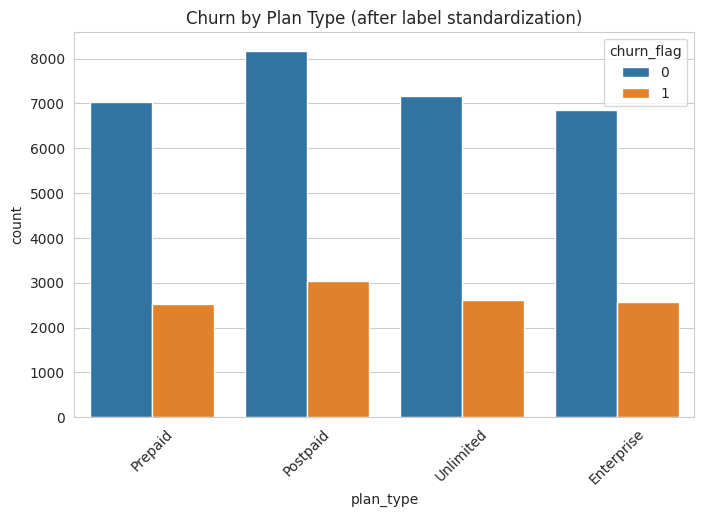

In [7]:
sns.countplot(data=df, x="plan_type", hue="churn_flag")
plt.title("Churn by Plan Type (after label standardization)")
plt.xticks(rotation=45)
plt.savefig(FIG_DIR / "plan_type_vs_churn.png", bbox_inches="tight")
plt.show()


## 3. Tenure and billing behavior

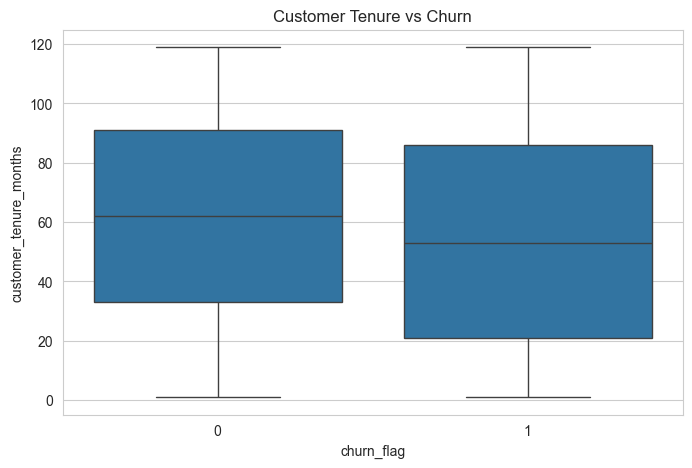

In [8]:
sns.boxplot(data=df, x="churn_flag", y="customer_tenure_months")
plt.title("Customer Tenure vs Churn")
plt.savefig(FIG_DIR / "tenure_vs_churn.png", bbox_inches="tight")
plt.show()


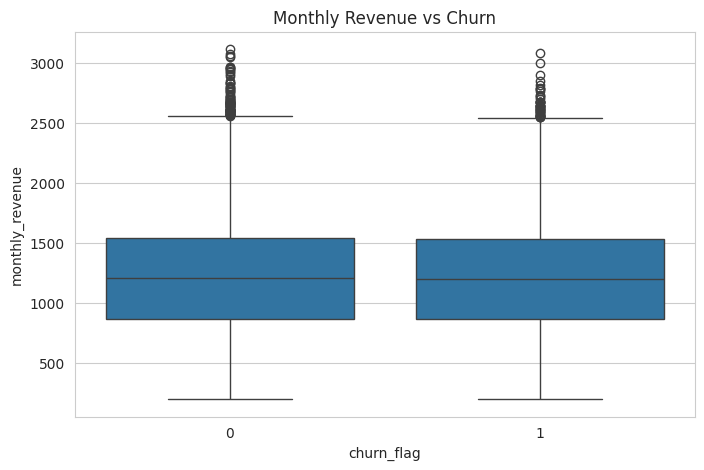

In [9]:
sns.boxplot(data=df, x="churn_flag", y="monthly_revenue")
plt.title("Monthly Revenue vs Churn")
plt.savefig(FIG_DIR / "monthly_revenue_vs_churn.png", bbox_inches="tight")
plt.show()


## 4. Correlation heatmap (numeric features)

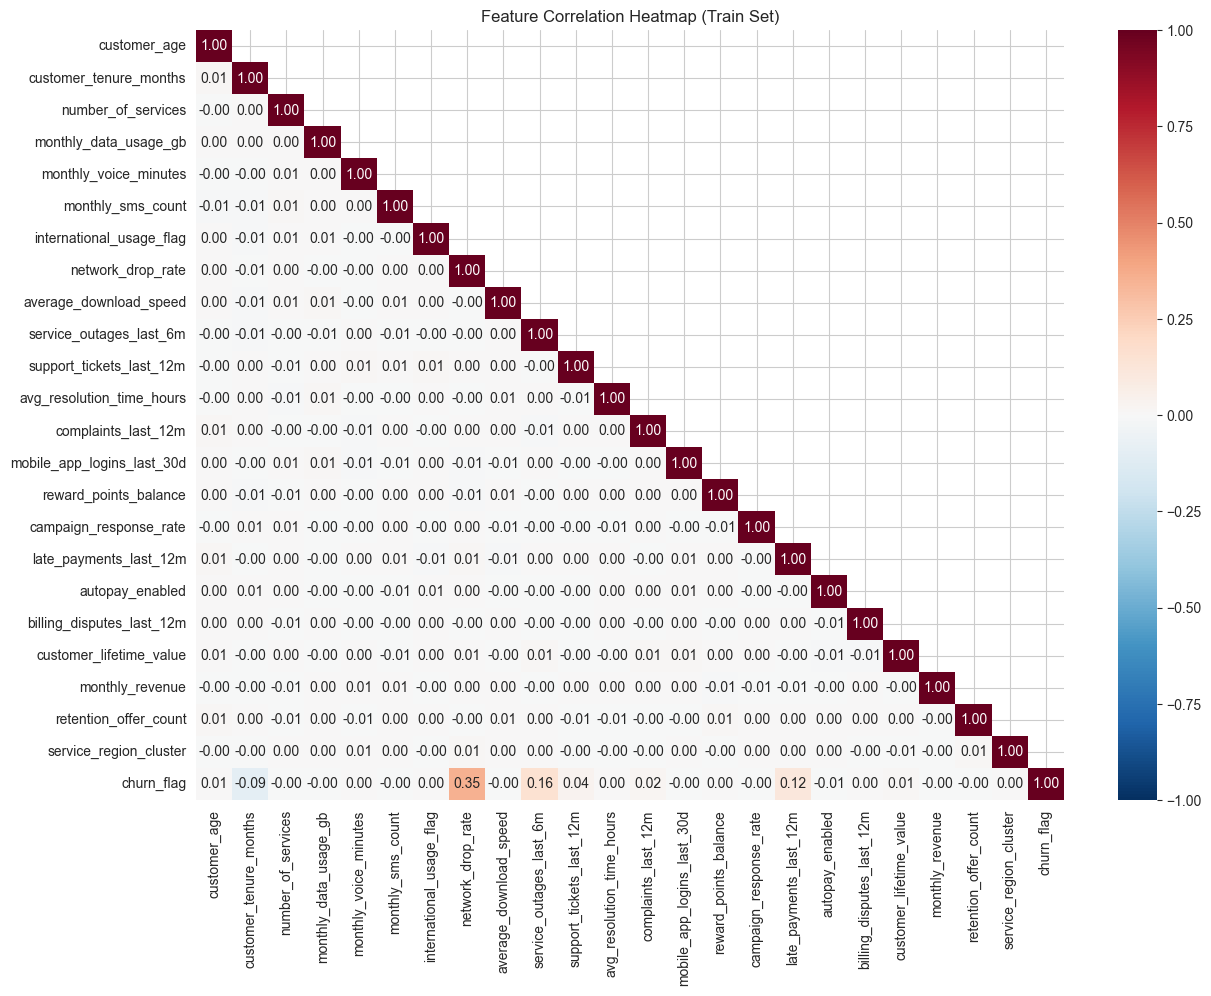

In [9]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool), k=1)

plt.figure(figsize=(14, 10))
sns.heatmap(
    numeric_df.corr(),
    mask=mask,
    cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f"
)
plt.title("Feature Correlation Heatmap (Train Set)")
plt.savefig(FIG_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()


## 5. Data-quality diagnostics used to design preprocessing (Notebook 3)

In [11]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values (train set only):")
print(missing)


Missing values (train set only):
average_download_speed    4110
campaign_response_rate    4056
monthly_data_usage_gb       84
dtype: int64


In [13]:
# Outlier scan using IQR rule on continuous numeric features
num_cols = [
    "customer_age", "customer_tenure_months", "monthly_revenue",
    "monthly_data_usage_gb", "monthly_voice_minutes", "monthly_sms_count",
    "network_drop_rate", "average_download_speed", "avg_resolution_time_hours",
    "customer_lifetime_value"
]

outlier_summary = []
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    outlier_summary.append({"feature": c, "n_outliers": n_out, "pct_outliers": round(n_out / len(df) * 100, 2)})

pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)


,feature,n_outliers,pct_outliers
8,avg_resolution_time_hours,837,2.07
3,monthly_data_usage_gb,773,1.91
9,customer_lifetime_value,295,0.73
5,monthly_sms_count,247,0.61
7,average_download_speed,235,0.58
2,monthly_revenue,127,0.31
4,monthly_voice_minutes,123,0.30
0,customer_age,0,0.00
1,customer_tenure_months,0,0.00
6,network_drop_rate,0,0.00


In [14]:
print("Skewness of continuous features:")
df[num_cols].skew().sort_values(ascending=False)


Skewness of continuous features:


avg_resolution_time_hours    0.985111
monthly_data_usage_gb        0.863311
monthly_sms_count            0.114554
monthly_revenue              0.110288
monthly_voice_minutes        0.049619
average_download_speed       0.032779
customer_lifetime_value      0.009336
customer_tenure_months       0.005053
network_drop_rate            0.002893
customer_age                -0.001801
dtype: float64

In [16]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.4 MB 6.6 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.4 MB 5.6 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.4 MB 5.4 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/11.4 MB 4.6 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.4 MB 4.3 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.4 MB 4.4 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.4 MB 4.5 MB/s eta 0:00:02
   ------------------------- -------------- 7.3/11.4 MB 4.4 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.4 MB 4.4 MB/s eta 0:00:01
   ------------------------------ --------- 8.7/11.4 MB 4.3 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.4 MB 4.2 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.4 MB 4.1 MB/s eta 0:00:01
   --

`avg_resolution_time_hours` (skew ~1.0) and `monthly_data_usage_gb` (still right-skewed after sentinel removal) are the most skewed continuous features and are good candidates for a log/power transform in preprocessing.

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [
    "customer_age", "customer_tenure_months", "monthly_revenue", "number_of_services",
    "monthly_data_usage_gb", "monthly_voice_minutes", "monthly_sms_count", "network_drop_rate",
    "average_download_speed", "service_outages_last_6m", "support_tickets_last_12m",
    "avg_resolution_time_hours", "complaints_last_12m", "mobile_app_logins_last_30d",
    "reward_points_balance", "campaign_response_rate", "late_payments_last_12m",
    "billing_disputes_last_12m", "customer_lifetime_value", "retention_offer_count"
]

vif_df = df[vif_cols].dropna()
vif_result = pd.DataFrame({
    "feature": vif_cols,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_cols))]
}).sort_values("VIF", ascending=False)

vif_result


,feature,VIF
6,monthly_sms_count,1.001030
12,complaints_last_12m,1.000962
13,mobile_app_logins_last_30d,1.000959
3,number_of_services,1.000889
14,reward_points_balance,1.000801
0,customer_age,1.000794
19,retention_offer_count,1.000771
8,average_download_speed,1.000765
1,customer_tenure_months,1.000747
18,customer_lifetime_value,1.000744


No extreme multicollinearity remains among numeric predictors once the duplicate `monthly_bill_amount` column is dropped (all VIFs are well below the common threshold of 10, aside from mild elevation), so no further numeric features need to be removed on that basis.